In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from run_exp import run_exp
import seaborn as sns
import torch.utils.benchmark as benchmark
from tqdm.notebook import tqdm, trange
import pandas as pd
from linear_algebra_utils import *

from figures.head_view import *

from notebook_utils import load_config, load_model, load_sampler, get_task_vectors, get_cos_sim_plot, get_id_icl_error, eval_tv_id_error, get_pos_loss

torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

### Remark at the beginning

When the trigger tokens are fixed, the attention pattern is not necessarily a clean Induction Head, since the TF can make use of the token embedding information. Below, we focus on the case where the trigger tokens are random.

### Instructions

To run an experiment, one can specify the length, vocabulary size, proportion of random tokens and Dirichlet prior parameter. To modify model parameters, please do it directly in the `run_exp` function.

Experiment directory:  results\frm\train_f37367d636fe585e3cdc6d10103e74f8
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Transformer                              [128, 512]                [128, 512, 6]             --
├─Embedding: 1-1                         [128, 512]                [128, 512, 64]            384
├─ModuleList: 1-2                        --                        --                        --
│    └─TFBlock: 2-1                      [128, 512, 64]            [128, 512, 64]            --
│    │    └─Identity: 3-1                [128, 512, 64]            [128, 512, 64]            --
│    │    └─MultiHeadAttention: 3-2      [128, 512, 64]            [128, 512, 64]            16,384
│    └─TFBlock: 2-2                      [128, 512, 64]            [128, 512, 64]            --
│    │    └─Identity: 3-3                [128, 512, 64]            [128, 512, 64]            --
│    │    └─MultiHeadAttention: 3-4      [128, 512, 

eval/CopyError,██▆▅▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/ICLLoss,█▇▅▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/IDLoss,█▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/OODLoss,█▇▆▅▅▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▇▅▅▄▅▄▃▃▃▃▁▃▂▂▂▃▂▃▂▁▃▁▃▂▁▃▂▁▂▂▂▂▁▂▂▂▂▁▂
train/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/CopyError,0.03628
eval/ICLLoss,1.5513
eval/IDLoss,1.42343
eval/OODLoss,1.56405


Starting training...
Step: 1000
Step: 2000
Step: 3000
Step: 4000
Step: 5000
Step: 6000
Step: 7000
Step: 8000
Step: 9000
Step: 10000
Step: 11000
Step: 12000
Step: 13000
Step: 14000
Step: 15000
Step: 16000
Step: 17000
Step: 18000
Step: 19000
Step: 20000
Training complete.
Loss plots saved at  results\frm\train_f37367d636fe585e3cdc6d10103e74f8\plots


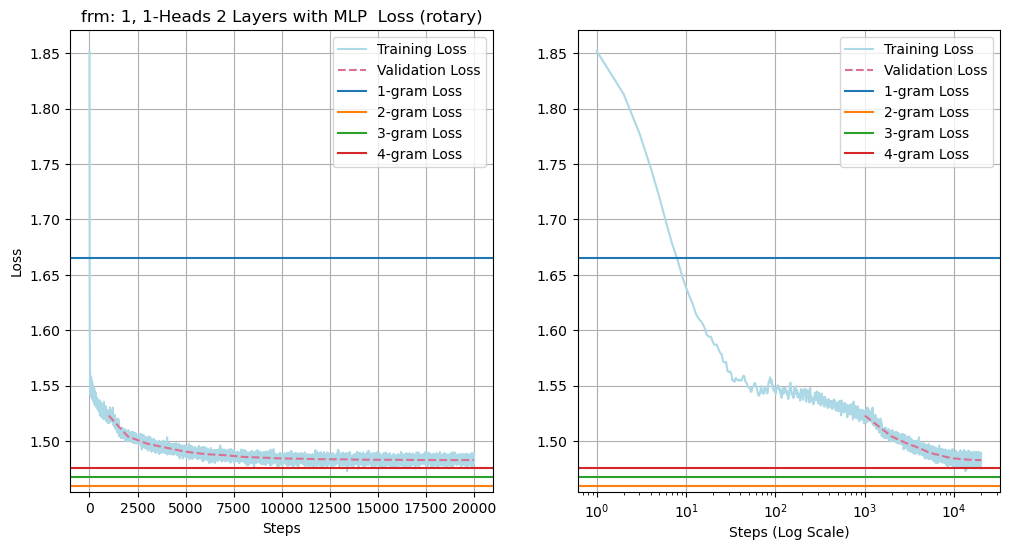

Probes plots saved at  results\frm\train_f37367d636fe585e3cdc6d10103e74f8\plots


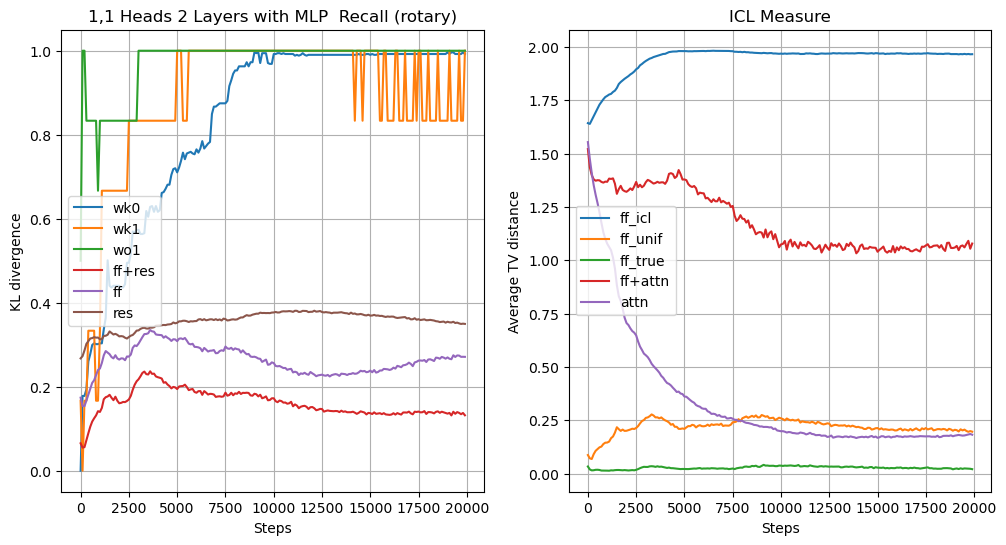

Probes plots saved at  results\frm\train_f37367d636fe585e3cdc6d10103e74f8\plots


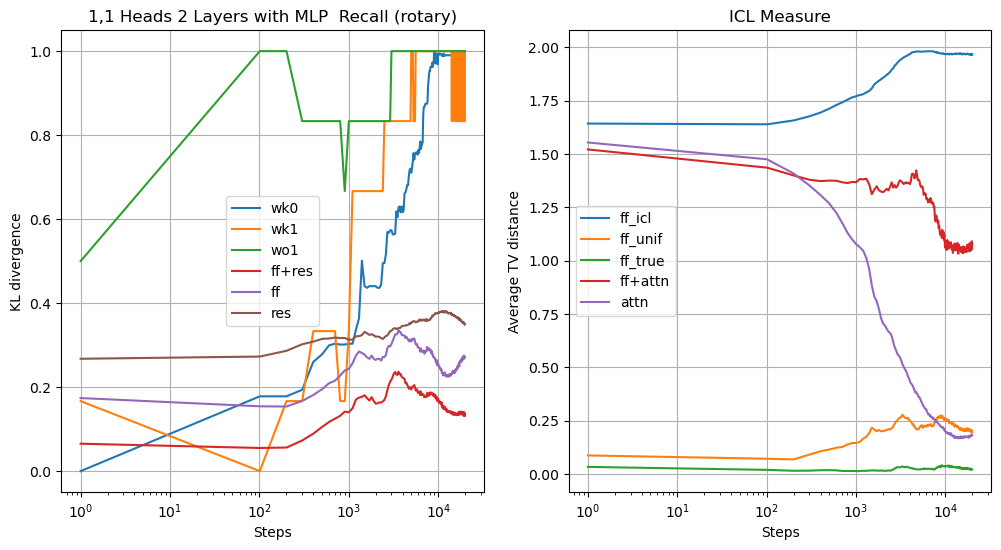

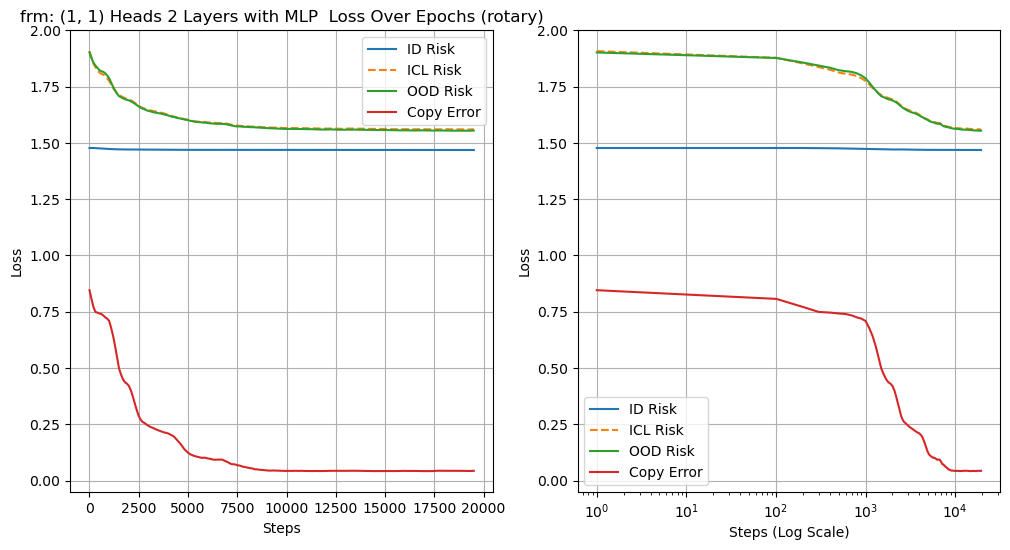

Creating images:   0%|          | 0/20 [00:00<?, ?it/s]

Creating images:   0%|          | 0/20 [00:00<?, ?it/s]

,


<IPython.core.display.Javascript object>

In [31]:
train_results, model = run_exp()

In [33]:
path_prefix = os.path.join("results", "frm")
train_folder = "train_f37367d636fe585e3cdc6d10103e74f8"
checkpoint_dir = os.path.join(path_prefix, train_folder, "checkpoints")
config_path = os.path.join(path_prefix, train_folder, "config.json")
sampler_path = os.path.join(path_prefix, train_folder, "sampler.pkl")
config = load_config(config_path)
model = load_model(checkpoint_dir, config)
sampler = load_sampler(sampler_path)

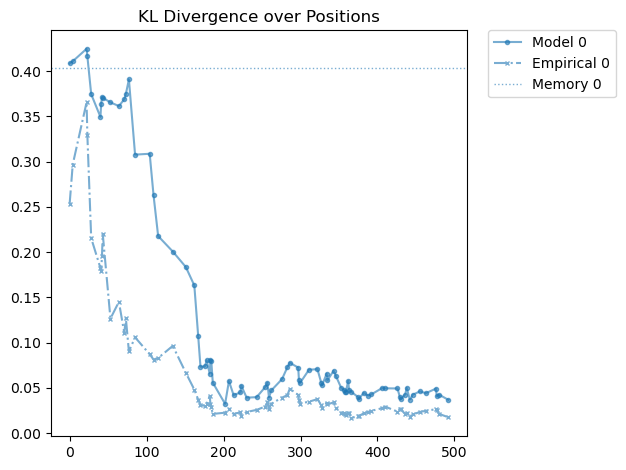

In [44]:
fig_path = os.path.join(path_prefix, train_folder, "plots")
result = get_pos_loss(model, sampler, mode="ood", folder=fig_path)

In [7]:
ffn = True
task_vecs = get_task_vectors(config, sampler, model, ffn=ffn)
kl_id_icl = get_id_icl_error(config, sampler, model)
print(kl_id_icl.mean())

In [8]:
kl = eval_tv_id_error(task_vecs, sampler, model, config, ffn)
print(kl.mean())

tensor(0.177)


In [10]:
effective_rank(task_vecs.numpy()), effective_rank(sampler.random_dist.task_pool)

(19.673473, 5.9091682)

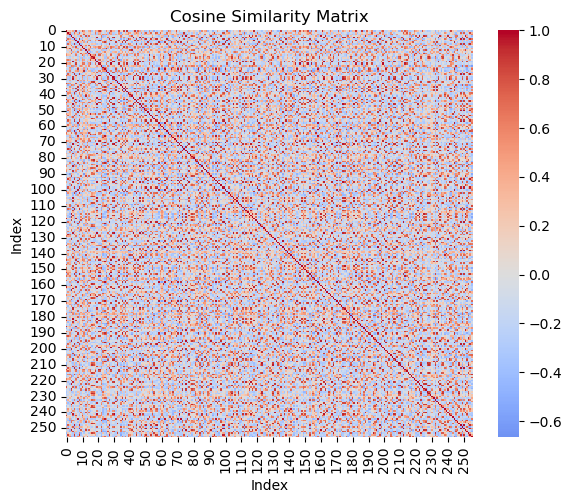

In [11]:
get_cos_sim_plot(task_vecs)

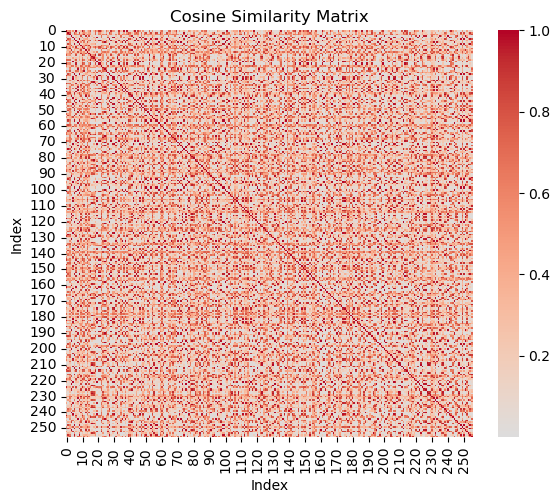

In [12]:
get_cos_sim_plot(sampler.random_dist.task_pool)

In [14]:
device = "cuda"
num_states = train_results["sampler"].num_states
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
range_toks = torch.arange(num_states).to(device)
toks = model.embed(range_toks)
task_vecs = (toks @ OV2).detach().cpu().numpy()
effective_rank(task_vecs), np.linalg.matrix_rank(task_vecs), stable_rank(task_vecs)

(5.3772855, 6, 3.352697356706975)

In [15]:
import itertools
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states*(num_states-1)//2)
for k, (i,j) in enumerate(list(itertools.combinations(range(num_states), 2))):
    hidden = (toks[i]/2 + toks[j]/2) @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(hidden+mlp_out))
    truth = zeros.clone()
    truth[i] = 0.5
    truth[j] = 0.5
    truth = truth / truth.sum()
    kl_div[k] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.2725215582177043

In [19]:
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states)
for i in range(num_states):
    hidden = toks[i] @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(mlp_out + hidden))
    truth = zeros.clone()
    truth[i] = 1
    truth = truth / truth.sum()
    kl_div[i] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.002496249658110609

In [21]:
device = "cuda"
num_states = train_results["sampler"].num_states
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
range_toks = torch.arange(num_states).to(device)
toks = model.embed(range_toks)
task_vecs = (toks @ OV2).detach().cpu().numpy()
effective_rank(task_vecs), np.linalg.matrix_rank(task_vecs), stable_rank(task_vecs)

(5.0915318, 6, 1.9765676742931142)

In [26]:
import itertools
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states*(num_states-1)//2)
for k, (i,j) in enumerate(list(itertools.combinations(range(num_states), 2))):
    hidden = (0.2*toks[i] + 0.8*toks[j]) @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(hidden+mlp_out))
    truth = zeros.clone()
    truth[i] = 0.2
    truth[j] = 0.8
    truth = truth / truth.sum()
    kl_div[k] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.22379331489404042

In [11]:
sampler = train_results["sampler"]
df = high_order_memory_probe_df(model)

KL divergence: 0.0129


In [76]:
tensor = torch.tensor([1, 2] * (256 // 2), dtype=torch.long, device="cuda").unsqueeze(0)
probe = torch.ones((1,256), dtype=torch.long, device="cuda")
probe[0][1] = 2
logits, attns = model(batch)

In [77]:
logits, attns = model(tensor)

In [111]:
tok = torch.tensor([1], device="cuda")
emb = model.embed(tok)
OV1 = model.layers[0].MHA.value.weight.T @ model.layers[0].MHA.out.weight.T
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
emb_tran = emb + emb @ (OV1 @ OV2 + OV1 + OV2)
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb@OV2)))

tensor([[    0.000,     1.000,     0.000,     0.000,     0.000]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [116]:
tok = torch.tensor([0,1,2,3,4], device="cuda")
emb = model.embed(tok)
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb + emb @ (OV1 @ OV2))))

tensor([[    0.152,     0.258,     0.215,     0.114,     0.261],
        [    0.905,     0.012,     0.035,     0.040,     0.008],
        [    0.017,     0.004,     0.956,     0.022,     0.000],
        [    0.178,     0.596,     0.071,     0.012,     0.143],
        [    0.814,     0.002,     0.000,     0.182,     0.002]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [115]:
sampler.trans_mat

tensor([[0.171, 0.078, 0.178, 0.035, 0.538],
        [0.074, 0.227, 0.562, 0.014, 0.123],
        [0.043, 0.475, 0.344, 0.110, 0.028],
        [0.283, 0.187, 0.124, 0.031, 0.374],
        [0.036, 0.186, 0.023, 0.696, 0.060]], device='cuda:0')

In [114]:
nn.Softmax(dim=-1)(model.output_layer(emb + emb @ (OV1 @ OV2)))

tensor([[    0.153,     0.042,     0.113,     0.578,     0.114],
        [    0.112,     0.139,     0.260,     0.363,     0.126],
        [    0.115,     0.290,     0.001,     0.529,     0.066],
        [    0.233,     0.045,     0.285,     0.224,     0.213],
        [    0.017,     0.030,     0.928,     0.011,     0.015]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [118]:
emb1 = model.embed(torch.tensor([3], device="cuda"))
emb2 = model.embed(torch.tensor([0], device="cuda"))
emb_tran = emb2 + emb1 @ OV2 + emb1 @ OV1 @ OV2
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb_tran) + emb_tran))

tensor([[    0.000,     0.000,     0.000,     1.000,     0.000]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [141]:
pattern = torch.tensor([2, 0, 2, 1])
n = 256
repeats = (n + len(pattern) - 1) // len(pattern)  
tensor = pattern.repeat(repeats)[:n].to("cuda").unsqueeze(0)
probs = nn.Softmax(dim=-1)(model(tensor)[0])[0][tensor[0]==2]
F.kl_div(sampler.trans_mat[2].log(), probs, reduction="none").sum(dim=-1)

tensor([0.010, 0.460, 0.002, 0.005, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.010, 0.001, 0.021, 0.001, 0.022, 0.002, 0.031,
        0.010, 0.059, 0.030, 0.115, 0.063, 0.163, 0.087, 0.168, 0.089, 0.172,
        0.112, 0.201, 0.169, 0.263, 0.245, 0.321, 0.298, 0.320, 0.304, 0.301,
        0.317, 0.309, 0.347, 0.318, 0.353, 0.276, 0.277, 0.222, 0.184, 0.185,
        0.143, 0.208, 0.165, 0.236, 0.184, 0.244, 0.184, 0.245, 0.197, 0.244,
        0.202, 0.249, 0.208, 0.252, 0.210, 0.246, 0.201, 0.231, 0.192, 0.214,
        0.190, 0.204, 0.188, 0.202, 0.187, 0.191, 0.174, 0.167, 0.149, 0.139,
        0.136, 0.124, 0.123, 0.110, 0.104, 0.082, 0.083, 0.055, 0.063, 0.049,
        0.073, 0.064, 0.093, 0.080, 0.098, 0.081, 0.098, 0.076, 0.095, 0.075,
        0.097, 0.089, 0.116, 0.094, 0.121, 0.096, 0.121, 0.096, 0.125, 0.099,
        0.130, 0.106, 0.136, 0.111, 0.139, 0.113, 0.140, 0.112, 0.140, 0.111,
        0.141, 0.112, 0.141, 0.118, 0.148, 0.117, 0.147, 0.116],

In [140]:
get_head_view(model, train_results, train_results["config"], trunc=0, action="view", batch=tensor)

<IPython.core.display.Javascript object>

triggers:  tensor([[0]], device='cuda:0')
outputs:  tensor([[2]], device='cuda:0')
Position:  251
--------------------------------------------------
Layer 1 KL divergence: 
--------------------
base : 0.002  ***   emb : 0.644    sa1 : 0.660    

--------------------
Layer 2 KL divergence: SA is second layer self attention applied to the output of the first layer
--------------------
sa2 : 1.025    out1 : 0.413    sa2+out1 : 0.002  ***   

--------------------------------------------------


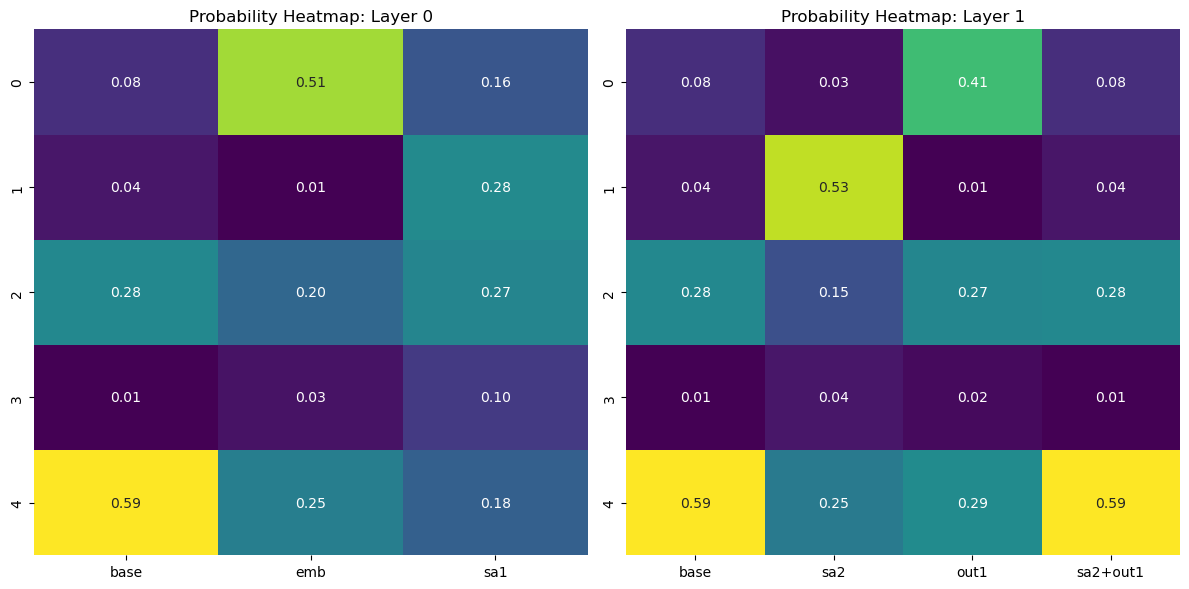

In [8]:
get_memory(model, tok=1)

triggers:  tensor([[10,  8, 12]], device='cuda:0')
outputs:  tensor([[ 8,  6, 10]], device='cuda:0')
triggers:  tensor([[4, 6, 1]], device='cuda:0')
outputs:  tensor([[13, 14, 11]], device='cuda:0')
Position:  113
--------------------------------------------------
Layer 1 KL divergence: 
--------------------
base : 0.001  ***   emb : 0.225  *   ffn(emb) : 0.190  *   ffn(emb)+emb : 0.085  **
sa1 : 0.377    ffn(sa1) : 0.415    

--------------------
Layer 2 KL divergence: SA is second layer self attention applied to the output of the first layer
--------------------
sa2 : 0.251  *   out1 : 0.377    sa2+out1 : 0.352    ffn(sa2) : 0.949 
ffn(sa2+out1) : 0.625    ffn(sa2+out1)+sa2 : 0.153  *   ffn(sa2+out1)+out1 : 0.297  *   

--------------------------------------------------


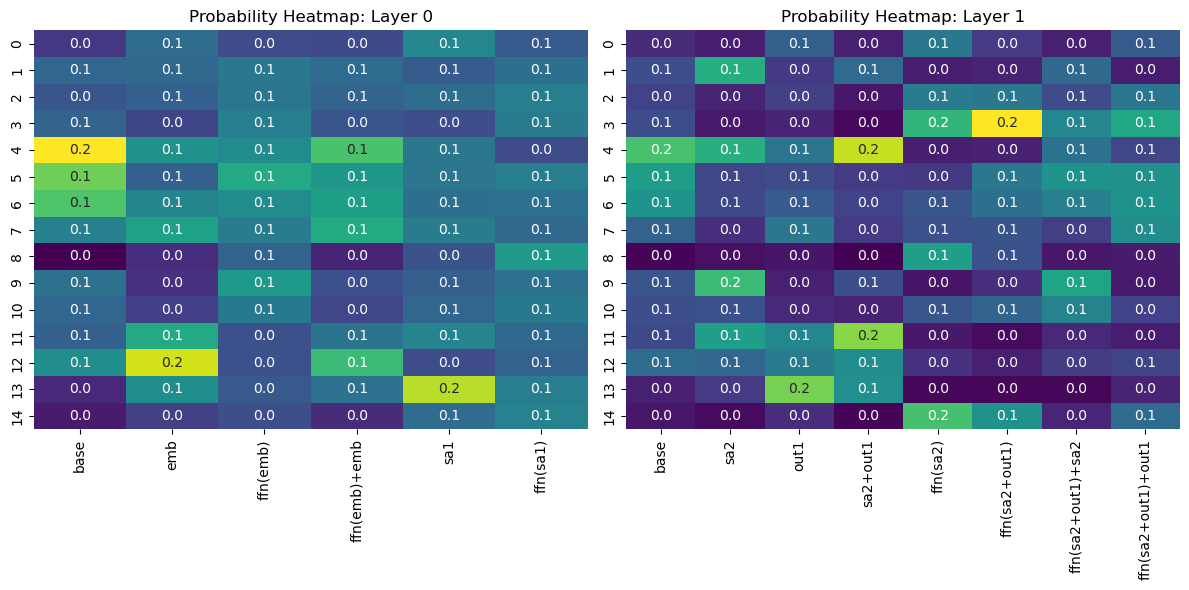

In [92]:
get_memory(model, tok=3)